## Provider_and_Supplier
The purpose of this notebook is to clean the DMEPOS - By Referral Provider and Service nad perform EDA on it. Additionally, multiple other datasets will be integrated with this data in the form of flags.

Tasks that were done:
- Integrated and cleaned the 2021–2023 DMEPOS referral provider datasets by standardizing string fields, assessing data quality, handling suppressed values, and adding year and suppression indicators.

- Enriched the data by linking to external sources (LEIE exclusion list and supplier dataset) to flag excluded providers and identify providers who also act as suppliers.

- Performed exploratory analysis and aggregation to compare excluded vs. non-excluded providers across utilization, payment metrics, service categories (RBCS), geography, time, and suppression patterns.

End result:

Saved the cleaned dataset to a shared team directory: /dsa/groups/casestudycf25/team02/DMEPOS_RefPro_Ser_nar_clean.csv

## Loading the data and quick exploration

In [1]:
# Loading Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

In [2]:
# A quick way to see what datasets are available in the team directory
for f in Path("/dsa/groups/casestudycf25/team02/").iterdir():
    print(f.name)

DMEPOS_suplr_2021.csv
Medicare_Monthly_Enrollment_Jun_2025.csv
DMEPOS_suplr_2022.csv
DMEPOS_suplr_2023.csv
DMEPOS_Supplier_Service_2021.csv
DMEPOS_Supplier_Service_2022.csv
DMEPOS_Supplier_Service_2023.csv
LEIE_OIG_Exclusion_List.csv
mup_dme_ry25_p05_v10_dy21_rfrhpr.csv
mup_dme_ry25_p05_v10_dy21_rfrr.csv
mup_dme_ry25_p05_v10_dy22_rfrhpr.csv
mup_dme_ry25_p05_v10_dy22_rfrr.csv
mup_dme_ry25_p05_v10_dy23_rfrhpr.csv
mup_dme_ry25_p05_v10_dy23_rfrr.csv
RUCA2010zipcode.csv
Taxonomy Code List Dec 2023.csv
leie_with_null_npi_clean.csv
leie_with_valid_npi_clean.csv
medicare_enrollment_clean.csv
CMS_General_Payments_2021_2023_raw.csv
casestudycf25t02.sqlite.db
DMEPOS_Bene_only_suplr.csv
DMEPOS_rfrhpr_clean.csv
DMEPOS_rfrr_clean.csv
DMEPOS_cleaned_serv.csv
DMEPOS_cleaned_grouping.csv
OWNRSHP_PGYR2021_2023.csv
ownership_payment_clean.csv
DMEPOS_rfrhpr_clean_labeled.csv
DMEPOS_rfrr_clean_labeled.csv
general_payments_manufacturers_clean.csv
general_payments_providers_clean.csv
general_payments-sliced_

In [5]:
# Loading the raw data
df21 = pd.read_csv(
    "/dsa/groups/casestudycf25/team02/mup_dme_ry25_p05_v10_dy21_rfrhpr.csv",
    dtype={"Suplr_Prvdr_RUCA": "float64"},
    na_values=["NA"]
)

df22 = pd.read_csv(
    "/dsa/groups/casestudycf25/team02/mup_dme_ry25_p05_v10_dy22_rfrhpr.csv",
    dtype={"Suplr_Prvdr_RUCA": "float64"},
    na_values=["NA"]
)

df23 = pd.read_csv(
    "/dsa/groups/casestudycf25/team02/mup_dme_ry25_p05_v10_dy23_rfrhpr.csv",
    dtype={"Suplr_Prvdr_RUCA": "float64"},
    na_values=["NA"]
)

C:\Users\kamat\AppData\Local\Temp\ipykernel_9724\306164269.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df21 = pd.read_csv(
C:\Users\kamat\AppData\Local\Temp\ipykernel_9724\306164269.py:7: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df22 = pd.read_csv(
C:\Users\kamat\AppData\Local\Temp\ipykernel_9724\306164269.py:13: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df23 = pd.read_csv(


In [6]:
#Data Types
df21.dtypes

Rfrg_NPI                      int64
Rfrg_Prvdr_Last_Name_Org     object
Rfrg_Prvdr_First_Name        object
Rfrg_Prvdr_MI                object
Rfrg_Prvdr_Crdntls           object
Rfrg_Prvdr_Ent_Cd            object
Rfrg_Prvdr_St1               object
Rfrg_Prvdr_St2               object
Rfrg_Prvdr_City              object
Rfrg_Prvdr_State_Abrvtn      object
Rfrg_Prvdr_State_FIPS        object
Rfrg_Prvdr_Zip5               int64
Rfrg_Prvdr_RUCA_Cat          object
Rfrg_Prvdr_RUCA             float64
Rfrg_Prvdr_RUCA_Desc         object
Rfrg_Prvdr_Cntry             object
Rfrg_Prvdr_Spclty_Cd         object
Rfrg_Prvdr_Spclty_Desc       object
Rfrg_Prvdr_Spclty_Srce       object
RBCS_Lvl                     object
RBCS_Id                      object
RBCS_Desc                    object
HCPCS_CD                     object
HCPCS_Desc                   object
Suplr_Rentl_Ind              object
Tot_Suplrs                    int64
Tot_Suplr_Benes             float64
Tot_Suplr_Clms              

Similar in structure and attributes to DMEPOS-Supplier & Service dataset

## Carpentry

In [7]:
import re

#2021
# Identify string/object columns
string_cols = [c for c in df21.columns if df21[c].dtype == "object"]

# Transforming all string variables into lowercase, removing special characters and replacing spaces with underscores
for c in string_cols:
    df21[c] = (
        df21[c]
        .astype(str)
        .str.lower()
        .str.replace(r"[^A-Za-z0-9\s]", "", regex=True)
        .str.replace(r"\s+", "_", regex=True)
    )

In [8]:
#2022
# Identify string/object columns
string_cols = [c for c in df22.columns if df22[c].dtype == "object"]

# Transforming all string variables into lowercase, removing special characters and replacing spaces with underscores
for c in string_cols:
    df22[c] = (
        df22[c]
        .astype(str)
        .str.lower()
        .str.replace(r"[^A-Za-z0-9\s]", "", regex=True)
        .str.replace(r"\s+", "_", regex=True)
    )

In [9]:
#2023
# Identify string/object columns
string_cols = [c for c in df23.columns if df23[c].dtype == "object"]

# Transforming all string variables into lowercase, removing special characters and replacing spaces with underscores
for c in string_cols:
    df23[c] = (
        df23[c]
        .astype(str)
        .str.lower()
        .str.replace(r"[^A-Za-z0-9\s]", "", regex=True)
        .str.replace(r"\s+", "_", regex=True)
    )

In [10]:
# Creating a single unified dataset

df23['Year'] = 2023
df22['Year'] = 2022
df21['Year'] = 2021

# Rearranging the columns
order21 = ["Year"] + [c for c in df21.columns if c != "Year"]
order22 = ["Year"] + [c for c in df22.columns if c != "Year"]
order23 = ["Year"] + [c for c in df23.columns if c != "Year"]

df21 = df21[order21]
df22 = df22[order22]
df23 = df23[order23]

df = pd.concat([df21, df22, df23], ignore_index=True)

In [11]:
# Checking..
df.head()

,Year,Rfrg_NPI,Rfrg_Prvdr_Last_Name_Org,Rfrg_Prvdr_First_Name,Rfrg_Prvdr_MI,Rfrg_Prvdr_Crdntls,Rfrg_Prvdr_Ent_Cd,Rfrg_Prvdr_St1,Rfrg_Prvdr_St2,Rfrg_Prvdr_City,...,HCPCS_Desc,Suplr_Rentl_Ind,Tot_Suplrs,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt
0,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,portable_gaseous_oxygen_system_rental_includes...,y,5,NaN,16,16,46.336250,20.097500,14.857500,15.280000
1,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,oxygen_concentrator_single_delivery_port_capab...,y,6,NaN,19,19,360.770000,98.223158,72.843684,79.753158
2,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,standard_hemi_low_seat_wheelchair,y,1,NaN,11,11,92.000000,39.230000,31.385455,33.552727
3,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,elevating_leg_rests_pair_for_use_with_capped_r...,y,1,NaN,11,11,20.000000,10.210909,8.169091,8.456364
4,2021,1003000480,rothchild,kevin,b,md,i,12605_e_16th_ave,nan,aurora,...,oxygen_concentrator_single_delivery_port_capab...,y,4,NaN,11,13,272.003846,80.513846,64.407692,84.701538


In [12]:
# Checking...
df.tail()

,Year,Rfrg_NPI,Rfrg_Prvdr_Last_Name_Org,Rfrg_Prvdr_First_Name,Rfrg_Prvdr_MI,Rfrg_Prvdr_Crdntls,Rfrg_Prvdr_Ent_Cd,Rfrg_Prvdr_St1,Rfrg_Prvdr_St2,Rfrg_Prvdr_City,...,HCPCS_Desc,Suplr_Rentl_Ind,Tot_Suplrs,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt
4413113,2023,1992999551,molai,indira,nan,md,i,625_e_grand_ave,nan,escondido,...,headgear_used_with_positive_airway_pressure_de...,n,4,NaN,15,15,54.000667,21.794667,17.090000,21.330000
4413114,2023,1992999551,molai,indira,nan,md,i,625_e_grand_ave,nan,escondido,...,filter_disposable_used_with_positive_airway_pr...,n,4,NaN,26,148,9.804189,2.351892,1.768649,2.527568
4413115,2023,1992999551,molai,indira,nan,md,i,625_e_grand_ave,nan,escondido,...,continuous_positive_airway_pressure_cpap_device,y,3,NaN,33,33,126.206970,34.797273,27.280909,41.530000
4413116,2023,1992999551,molai,indira,nan,md,i,625_e_grand_ave,nan,escondido,...,oxygen_concentrator_single_delivery_port_capab...,y,1,NaN,12,12,362.000000,85.000000,61.086667,93.711667
4413117,2023,1992999551,molai,indira,nan,md,i,625_e_grand_ave,nan,escondido,...,portable_oxygen_concentrator_rental,y,1,NaN,12,12,125.000000,43.150000,31.010833,33.349167


In [13]:
# Shape
df.shape

(4413118, 34)

In [14]:
# Checking fo null values
nulls = df.isna().sum()
nulls

Year                              0
Rfrg_NPI                          0
Rfrg_Prvdr_Last_Name_Org          0
Rfrg_Prvdr_First_Name             0
Rfrg_Prvdr_MI                     0
Rfrg_Prvdr_Crdntls                0
Rfrg_Prvdr_Ent_Cd                 0
Rfrg_Prvdr_St1                    0
Rfrg_Prvdr_St2                    0
Rfrg_Prvdr_City                   0
Rfrg_Prvdr_State_Abrvtn           0
Rfrg_Prvdr_State_FIPS             0
Rfrg_Prvdr_Zip5                   0
Rfrg_Prvdr_RUCA_Cat               0
Rfrg_Prvdr_RUCA                3509
Rfrg_Prvdr_RUCA_Desc              0
Rfrg_Prvdr_Cntry                  0
Rfrg_Prvdr_Spclty_Cd              0
Rfrg_Prvdr_Spclty_Desc            0
Rfrg_Prvdr_Spclty_Srce            0
RBCS_Lvl                          0
RBCS_Id                           0
RBCS_Desc                         0
HCPCS_CD                          0
HCPCS_Desc                        0
Suplr_Rentl_Ind                   0
Tot_Suplrs                        0
Tot_Suplr_Benes             

RUCA-related attributes will be kept for analysis purposes.

In [16]:
# Suppression indicator for analysis
df["DME_Sprsn_Ind"] = df["Tot_Suplr_Benes"].isna().map({True: "y", False: "n"})
df.head()

,Year,Rfrg_NPI,Rfrg_Prvdr_Last_Name_Org,Rfrg_Prvdr_First_Name,Rfrg_Prvdr_MI,Rfrg_Prvdr_Crdntls,Rfrg_Prvdr_Ent_Cd,Rfrg_Prvdr_St1,Rfrg_Prvdr_St2,Rfrg_Prvdr_City,...,Suplr_Rentl_Ind,Tot_Suplrs,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt,DME_Sprsn_Ind
0,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,y,5,NaN,16,16,46.336250,20.097500,14.857500,15.280000,y
1,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,y,6,NaN,19,19,360.770000,98.223158,72.843684,79.753158,y
2,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,y,1,NaN,11,11,92.000000,39.230000,31.385455,33.552727,y
3,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,y,1,NaN,11,11,20.000000,10.210909,8.169091,8.456364,y
4,2021,1003000480,rothchild,kevin,b,md,i,12605_e_16th_ave,nan,aurora,...,y,4,NaN,11,13,272.003846,80.513846,64.407692,84.701538,y


In [17]:
#Add in suppression indicator before total beneficiaries
cols = df.columns.tolist()
cols.remove("DME_Sprsn_Ind")

# Find index of Tot_Suplr_Benes
idx = cols.index("Tot_Suplr_Benes")

# Insert DME_Sprsn_Ind after Tot_Suplr_Benes
cols.insert(idx, "DME_Sprsn_Ind")

# Reorder dataframe
df = df[cols]
df.head()

,Year,Rfrg_NPI,Rfrg_Prvdr_Last_Name_Org,Rfrg_Prvdr_First_Name,Rfrg_Prvdr_MI,Rfrg_Prvdr_Crdntls,Rfrg_Prvdr_Ent_Cd,Rfrg_Prvdr_St1,Rfrg_Prvdr_St2,Rfrg_Prvdr_City,...,Suplr_Rentl_Ind,Tot_Suplrs,DME_Sprsn_Ind,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt
0,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,y,5,y,NaN,16,16,46.336250,20.097500,14.857500,15.280000
1,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,y,6,y,NaN,19,19,360.770000,98.223158,72.843684,79.753158
2,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,y,1,y,NaN,11,11,92.000000,39.230000,31.385455,33.552727
3,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,y,1,y,NaN,11,11,20.000000,10.210909,8.169091,8.456364
4,2021,1003000480,rothchild,kevin,b,md,i,12605_e_16th_ave,nan,aurora,...,y,4,y,NaN,11,13,272.003846,80.513846,64.407692,84.701538


## EDA

In [20]:
# Loading the LEIE exclusion list
d = pd.read_csv("/dsa/groups/casestudycf25/team02/leie_with_valid_npi_clean.csv",
                dtype={"Suplr_Prvdr_RUCA": "float64"}, na_values=["NA"])

In [21]:
# Few rows of the cleaned exclusion list
d.head()

,general,specialty,npi,excltype,excldate,num_exclusions_alltime,num_exclusion_types_alltime,list_exclusion_types_alltime,num_addresses_alltime,new_id,fraud_flag,excl_1128a1,excl_1128a2,excl_1128a3,excl_1128b5,excl_1128b6,excl_1128b7,excl_brch cia
0,IND- LIC HC SERV PRO,DENTIST,1861529091,1128a3,3/20/2024,1,1,['1128a3'],1,AAMIR-WAHAB-nan-1979-11-16,1,0,0,1,0,0,0,0
1,IND- LIC HC SERV PRO,CHIROPRACTIC,1366544512,1128b7,8/16/2021,1,1,['1128b7'],1,AARON-OXENRIDER-nan-1976-06-07,1,0,0,0,0,0,1,0
2,IND- LIC HC SERV PRO,HEALTH CARE AIDE,1376214585,1128a1,1/20/2025,1,1,['1128a1'],1,AARON-WALTON-nan-1971-11-19,1,1,0,0,0,0,0,0
3,BUS OWNER/EXEC,COUNSELING CENTER,1326353459,1128a1,3/20/2022,1,1,['1128a1'],1,AARON-WILLIAMS-nan-1962-10-20,1,1,0,0,0,0,0,0
4,BUS OWNER/EXEC,ASSISTED LIVING FACI,1578130340,1128a1,7/20/2025,1,1,['1128a1'],1,ABDOULIE-LOWE-nan-1975-12-27,1,1,0,0,0,0,0,0


In [22]:
# Flag NPIs in the main dataset that are listed in the LEIE exclusion list
npi_e = d["npi"]
df["Excluded"] = df['Rfrg_NPI'].isin(npi_e).map({True: "y", False: "n"})
df.head()

,Year,Rfrg_NPI,Rfrg_Prvdr_Last_Name_Org,Rfrg_Prvdr_First_Name,Rfrg_Prvdr_MI,Rfrg_Prvdr_Crdntls,Rfrg_Prvdr_Ent_Cd,Rfrg_Prvdr_St1,Rfrg_Prvdr_St2,Rfrg_Prvdr_City,...,Tot_Suplrs,DME_Sprsn_Ind,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt,Excluded
0,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,5,y,NaN,16,16,46.336250,20.097500,14.857500,15.280000,n
1,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,6,y,NaN,19,19,360.770000,98.223158,72.843684,79.753158,n
2,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,1,y,NaN,11,11,92.000000,39.230000,31.385455,33.552727,n
3,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,1,y,NaN,11,11,20.000000,10.210909,8.169091,8.456364,n
4,2021,1003000480,rothchild,kevin,b,md,i,12605_e_16th_ave,nan,aurora,...,4,y,NaN,11,13,272.003846,80.513846,64.407692,84.701538,n


In [23]:
# How many NPIs in the main dataset are on the LEIE exclusion list?
df[df['Excluded'] == 'y'].shape[0]

1413

In [24]:
# Number of unique NPIs in df that are excluded
df[df['Excluded'] == 'y']['Rfrg_NPI'].nunique()

109

In [25]:
# Compare the count of unique providers who are excluded versus those who are not
df.groupby('Excluded')['Rfrg_NPI'].nunique()

Excluded
n    397925
y       109
Name: Rfrg_NPI, dtype: int64

In [26]:
# Impact of excluded NPIs on total supplier counts, claims, and beneficiaries
df.groupby('Excluded')[['Tot_Suplrs', 'Tot_Suplr_Clms', 'Tot_Suplr_Benes']].sum()

,Tot_Suplrs,Tot_Suplr_Clms,Tot_Suplr_Benes
Excluded,,,
n,19195219,187259369,48878492.0
y,6338,86504,45194.0


In [27]:
# Compare the typical submitted charges and Medicare payment amounts for excluded versus non-excluded NPIs,
df.groupby('Excluded')[['Avg_Suplr_Sbmtd_Chrg', 'Avg_Suplr_Mdcr_Alowd_Amt',
                        'Avg_Suplr_Mdcr_Pymt_Amt', 'Avg_Suplr_Mdcr_Stdzd_Amt']].mean()

,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt
Excluded,,,,
n,209.177703,75.420068,57.661215,58.989667
y,240.571358,104.842301,80.412737,81.477922


In [28]:
# Which states have the most excluded providers?
df.groupby(['Rfrg_Prvdr_State_Abrvtn', 'Excluded'])['Rfrg_NPI'].nunique().unstack().fillna(0).sort_values(by='y', ascending=False).head(10)

Excluded,n,y
Rfrg_Prvdr_State_Abrvtn,,
tx,25408.0,16.0
ca,33513.0,14.0
mi,13954.0,11.0
il,16256.0,7.0
oh,15942.0,7.0
pa,19651.0,6.0
mo,8257.0,4.0
ny,24158.0,4.0
ms,4305.0,4.0


In [29]:
# Top 10 states with the highest number of referral providers
df.groupby('Rfrg_Prvdr_State_Abrvtn')['Rfrg_NPI'].size().sort_values(ascending=False).head(10)

Rfrg_Prvdr_State_Abrvtn
ca    358034
fl    282002
tx    280701
ny    228294
pa    203747
il    188691
oh    164020
nc    151197
mi    145345
va    119008
Name: Rfrg_NPI, dtype: int64

In [30]:
# States most affected by LEIE exclusions
df.groupby(['Rfrg_Prvdr_State_Abrvtn', 'Excluded'])['Rfrg_NPI'].size().unstack().fillna(0).sort_values(by='y', ascending=False).head(10)

Excluded,n,y
Rfrg_Prvdr_State_Abrvtn,,
ca,357786.0,248.0
tx,280501.0,200.0
ok,69427.0,153.0
pa,203627.0,120.0
mi,145237.0,108.0
mo,110078.0,103.0
tn,113487.0,96.0
il,188623.0,68.0
wa,84247.0,40.0


In [32]:
# Cities with the largest number of excluded provider records
df[df['Excluded']=='y'].groupby('Rfrg_Prvdr_City').size().sort_values(ascending=False).head(10)

Rfrg_Prvdr_City
oklahoma_city    152
scranton          71
jackson           68
joplin            60
detroit           54
denton            52
burbank           46
dallas            46
farmington        45
northridge        41
dtype: int64

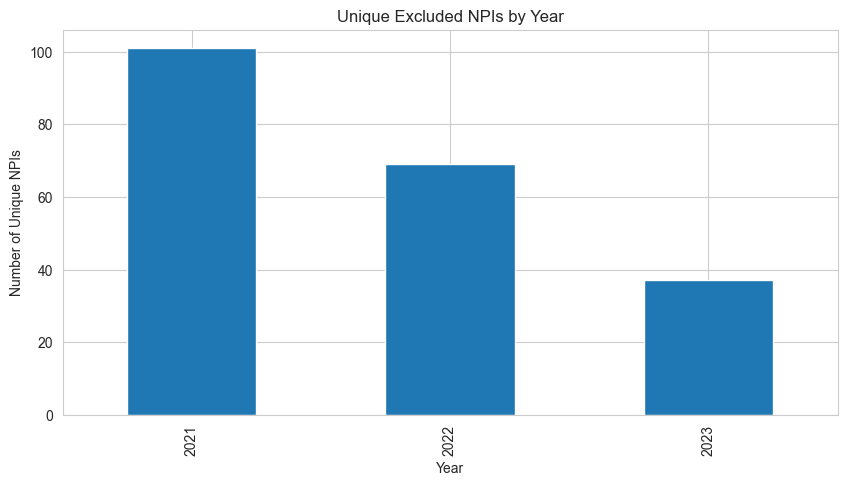

In [33]:
# Excluded NPIs count over time
ax = (
    df[df['Excluded'] == 'y']
    .groupby(['Year', 'Excluded'])['Rfrg_NPI']
    .nunique()
    .unstack()
    .plot(kind='bar', figsize=(10,5))
)


ax.set_facecolor('white')            
ax.figure.patch.set_facecolor('white')  

ax.set_title("Unique Excluded NPIs by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Unique NPIs")
ax.legend().remove()

In [34]:
# Count of NPIs excluded each year
df[df['Excluded'] == 'y'].groupby(['Year', 'Excluded'])['Rfrg_NPI'].nunique().unstack()

Excluded,y
Year,
2021,101
2022,69
2023,37


In [39]:
#Loading derived supplier dataset
df_sup = pd.read_csv("/dsa/groups/casestudycf25/team02/DMEPOS_Bene_only_suplr.csv")
df_sup.head()

,Year,Suplr_NPI,Bene_Avg_Age,Bene_Feml_Cnt,Bene_Male_Cnt,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_Api_Cnt,Bene_Race_Hspnc_Cnt,Bene_Race_Natind_Cnt,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
0,2021,1003000399,72.919149,163.0,69.0,211.0,NaN,NaN,0.0,0.0,...,0.271552,0.120690,0.741379,0.650862,0.215517,0.189655,NaN,0.676724,0.094828,0.982410
1,2021,1003002254,71.058824,32.0,23.0,55.0,0.0,0.0,0.0,0.0,...,0.854545,0.236364,0.818182,0.836364,0.363636,NaN,NaN,0.272727,NaN,1.500596
2,2021,1003004904,74.692308,NaN,NaN,19.0,NaN,0.0,NaN,0.0,...,1.190476,NaN,1.095238,1.190476,0.809524,NaN,NaN,0.571429,NaN,2.327878
3,2021,1003004938,67.707692,42.0,24.0,62.0,NaN,0.0,0.0,0.0,...,0.757576,0.242424,0.757576,0.787879,0.318182,NaN,NaN,0.363636,NaN,1.693562
4,2021,1003007386,71.547619,22.0,16.0,37.0,NaN,0.0,0.0,0.0,...,1.000000,NaN,0.947368,0.973684,NaN,NaN,0.0,0.342105,NaN,1.188676


In [40]:
# Flagging which referral providers also act as suppliers
npi_s = df_sup['Suplr_NPI']
df["Supplier"] = df['Rfrg_NPI'].isin(npi_s).map({True: "y", False: "n"})
df.head()

,Year,Rfrg_NPI,Rfrg_Prvdr_Last_Name_Org,Rfrg_Prvdr_First_Name,Rfrg_Prvdr_MI,Rfrg_Prvdr_Crdntls,Rfrg_Prvdr_Ent_Cd,Rfrg_Prvdr_St1,Rfrg_Prvdr_St2,Rfrg_Prvdr_City,...,DME_Sprsn_Ind,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt,Excluded,Supplier
0,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,y,NaN,16,16,46.336250,20.097500,14.857500,15.280000,n,n
1,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,y,NaN,19,19,360.770000,98.223158,72.843684,79.753158,n,n
2,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,y,NaN,11,11,92.000000,39.230000,31.385455,33.552727,n,n
3,2021,1003000126,enkeshafi,ardalan,nan,md,i,6410_rockledge_dr_ste_304,nan,bethesda,...,y,NaN,11,11,20.000000,10.210909,8.169091,8.456364,n,n
4,2021,1003000480,rothchild,kevin,b,md,i,12605_e_16th_ave,nan,aurora,...,y,NaN,11,13,272.003846,80.513846,64.407692,84.701538,n,n


In [42]:
# Distribution of providers acting as suppliers
df['Supplier'].value_counts()

Supplier
n    4410619
y       2499
Name: count, dtype: int64

In [43]:
# Summarizes the relationship between being a supplier and being excluded
pd.crosstab(df['Supplier'], df['Excluded'], margins=True)

Excluded,n,y,All
Supplier,,,
n,4409206,1413,4410619
y,2499,0,2499
All,4411705,1413,4413118


In [44]:
# Summarizes the distribution of suppliers across different RBCS levels
pd.crosstab(df['RBCS_Lvl'], df['Supplier'])

Supplier,n,y
RBCS_Lvl,,
drugs_administered_through_dme,208209,2
durable_medical_equipment,3526472,417
nondme,1,0
orthotic_devices,354230,1486
unknown,321707,594


In [45]:
# Are excluded NPIs also suppressed
suppressed_excluded_count = df[(df["DME_Sprsn_Ind"] == 'y') & (df["Excluded"] == 'y')].shape[0]
suppressed_excluded_count

938

In [46]:
# Top 5 states with most suppressed entries
suppressed_by_state = (
    df[df["DME_Sprsn_Ind"] == 'y']
    .groupby("Rfrg_Prvdr_State_Abrvtn")
    .size()
    .reset_index(name="Suppressed_Count")
    .sort_values("Suppressed_Count", ascending=False)
)

suppressed_by_state.head()

,Rfrg_Prvdr_State_Abrvtn,Suppressed_Count
7,ca,255399
49,tx,197804
12,fl,185552
39,ny,160289
43,pa,145446


In [49]:
# Suppresed and Excluded by State
excluded_by_state = (
    df[(df["DME_Sprsn_Ind"] == 'y') & (df["Excluded"] == 'y')]
    .groupby("Rfrg_Prvdr_State_Abrvtn")
    .size()
    .reset_index(name="Excluded_Count")
    .sort_values("Excluded_Count", ascending=False)
)
excluded_by_state

,Rfrg_Prvdr_State_Abrvtn,Excluded_Count
4,ca,177
26,tx,147
24,pa,91
23,ok,84
14,mi,76
15,mo,70
25,tn,65
10,il,34
27,va,27
16,ms,26


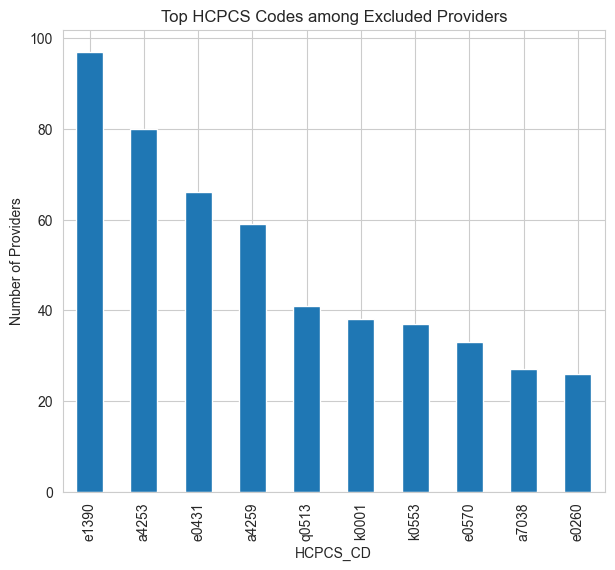

In [50]:
# Top HCPCS Codes among Excluded Providers
plt.figure(figsize=(7,6))
top_hcpcs = df[df['Excluded']=='y'].groupby('HCPCS_CD')['Rfrg_NPI'].count().sort_values(ascending=False).head(10)
top_hcpcs.plot(kind='bar')
plt.title('Top HCPCS Codes among Excluded Providers')
plt.ylabel('Number of Providers')
plt.show()

In [51]:
# The distribution of excluded vs non-excluded providers across RBCS levels
df.groupby(['RBCS_Lvl', 'Excluded'])['Rfrg_NPI'].count().unstack(fill_value=0)

Excluded,n,y
RBCS_Lvl,,
drugs_administered_through_dme,208152,59
durable_medical_equipment,3525823,1066
nondme,1,0
orthotic_devices,355498,218
unknown,322231,70


In [52]:
#Specialty with most exclusions
df[df['Excluded']=='y']['Rfrg_Prvdr_Crdntls'].value_counts().head(10)

Rfrg_Prvdr_Crdntls
md             1111
do              161
md_phd           28
apn              24
dpm              16
fnpbc            15
pac              14
phd_md           11
aprn_bc_npc       8
np                6
Name: count, dtype: int64

In [54]:
# Midwest Exclusion

midwest_states = ['mo', 'il', 'ks', 'ia', 'ne', 'mn', 'wi', 'sd', 'nd', 'mi', 'oh', 'in']
df_midwest = df[df['Rfrg_Prvdr_State_Abrvtn'].isin(midwest_states)]

midwest_ratio = df_midwest['Excluded'].value_counts()
print(midwest_ratio)

Excluded
n    1105862
y        326
Name: count, dtype: int64


In [41]:
#Saving the file
df.to_csv("/dsa/groups/casestudycf25/team02/DMEPOS_RefPro_Ser_nar_clean.csv",index=False)